--- Task 1 Sanity Check ---
Multiply Gate: x=2, y=3. dx=3, dy=2 (Expected: 3, 2)

--- Task 2: 1-1-1 Network Trace ---
Forward Pass: y_hat=10.0, Loss=40.5
Calculated Gradients: dw1=54.0, dw2=45.0
Expected Gradients:   dw1=54.0, dw2=45.0
SUCCESS: Gradients match the lecture!

--- Task 3: Vanishing Gradients ---
Plot generated. Close the plot window to finish the lab.


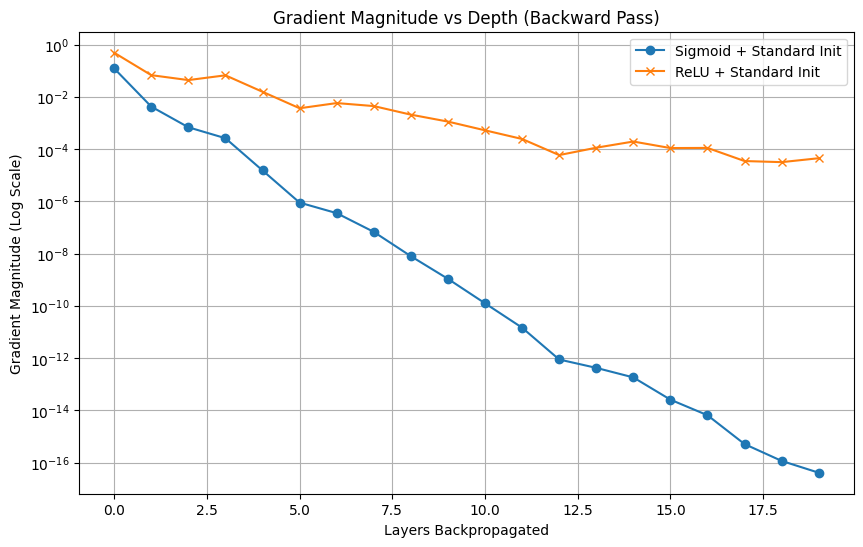

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# TASK 1: The Computational Graph Gates
# ==========================================
# In the lecture, we defined "Gates" that compute a Local Gradient
# and multiply it by an Upstream Gradient.
#
# Your task: Implement the backward() methods for these gates.

class MultiplyGate:
    def forward(self, x, y):
        self.x = x
        self.y = y
        return x * y

    def backward(self, dout):
        """
        dout: The upstream gradient (derivative of L w.r.t output of this gate)
        Returns: Tuple (dx, dy)

        Lecture Reference: The Multiply Gate acts as a "Switcher".
        dx should be dout * ...
        dy should be dout * ...
        """
        # TODO: Implement the backward pass for multiplication
        dx = dout * self.y
        dy = dout * self.x
        return dx, dy

class AddGate:
    def forward(self, x, y):
        return x + y

    def backward(self, dout):
        """
        Lecture Reference: The Add Gate is a "Gradient Distributor".
        """
        # TODO: Implement backward pass for addition
        dx = dout
        dy = dout
        return dx, dy

class ReLUGate:
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, dout):
        """
        Lecture Reference: The ReLU/Max Gate is a "Router".
        If x > 0, gradient flows (1 * dout).
        If x <= 0, gradient dies (0).
        """
        # TODO: Implement backward pass for ReLU
        if x > 0:
          dx = 1 * dout

        else:
          dx = 0

        return dx

print("--- Task 1 Sanity Check ---")
# Example: f = x * y. Let x=2, y=3. Upstream grad (dout) = 1.
# dx should be 3, dy should be 2.
mul = MultiplyGate()
res = mul.forward(2, 3)
dx, dy = mul.backward(1)
print(f"Multiply Gate: x=2, y=3. dx={dx}, dy={dy} (Expected: 3, 2)")


# ==========================================
# TASK 2: The 1-1-1 Network Walkthrough
# ==========================================
# We will recreate the exact numerical example from the Lecture 4 Walkthrough.
# Setup:
# Input x=2, Target y=1
# w1=2, b1=1
# w2=3, b2=-5
# Loss = 0.5 * (y_hat - y)^2

def manual_neural_net_step():
    # 1. Initialize Variables (From Lecture)
    x = 2.0
    y_target = 1.0
    w1 = 2.0
    b1 = 1.0
    w2 = 3.0
    b2 = -5.0

    print(f"\n--- Task 2: 1-1-1 Network Trace ---")

    # --- FORWARD PASS ---
    z1 = w1 * x + b1        # Hidden pre-activation
    h1 = max(0, z1)         # ReLU activation
    z2 = w2 * h1 + b2       # Output pre-activation
    y_hat = z2              # Linear output
    loss = 0.5 * (y_hat - y_target)**2

    print(f"Forward Pass: y_hat={y_hat}, Loss={loss}")

    # --- BACKWARD PASS ---
    # Step 1: gradient at output
    dL_dyhat = y_hat - y_target  # derivative of 0.5*(y_hat - y)^2 w.r.t y_hat

    # Step 2: gradient w.r.t w2
    dL_dw2 = dL_dyhat * h1      # dz2/dw2 = h1

    # Step 3: gradient w.r.t b2
    dL_db2 = dL_dyhat            # dz2/db2 = 1

    # Step 4: gradient w.r.t hidden output h1
    dL_dh1 = dL_dyhat * w2       # dz2/dh1 = w2

    # Step 5: gradient w.r.t hidden pre-activation z1 (through ReLU)
    dL_dz1 = dL_dh1 * (1 if z1 > 0 else 0)  # ReLU derivative

    # Step 6: gradient w.r.t w1
    dL_dw1 = dL_dz1 * x          # dz1/dw1 = x

    # Step 7: gradient w.r.t b1
    dL_db1 = dL_dz1               # dz1/db1 = 1

    print(f"Calculated Gradients: dw1={dL_dw1}, dw2={dL_dw2}")
    print(f"Expected Gradients:   dw1=54.0, dw2=45.0")

    # Verification
    if np.isclose(dL_dw1, 54.0) and np.isclose(dL_dw2, 45.0):
        print("SUCCESS: Gradients match the lecture!")
    else:
        print("FAILURE: Gradients do not match. Check your chain rule logic.")

manual_neural_net_step()


# ==========================================
# TASK 3: The Vanishing Gradient Experiment
# ==========================================
# We will verify why deep networks failed before ReLU.
# We will simulate a deep chain of multiplications:
# grad = Product(activation_derivative(z) * weight)

def simulate_deep_network(depth, activation_type='sigmoid'):
    # Assume weights are initialized randomly from Normal Distribution
    # Standard Init: Mean=0, Std=1
    np.random.seed(42) # Fixed seed for reproducibility
    weights = np.random.randn(depth)

    # Assume input is small
    x = 0.5

    # We will track the magnitude of the gradient as it flows BACKWARDS
    # Start with a gradient of 1.0 at the loss
    current_grad = 1.0

    grad_magnitudes = []

    # Iterate backwards from last layer to first
    for i in range(depth):
        w = weights[i]

        # Local Gradient of the Activation
        if activation_type == 'sigmoid':
            # Max derivative of sigmoid is 0.25
            
            #we chose 0.25 because that's the best we can take , and this will also result in vanishing gradients 
            #0.25 is coming from the derivative because we're calculating gradients at the end of the day 
            #will relu also fail ? 
            #yes it can fail if we've reached a -ve value so the function will always generate 0 outputs so it'll stop learning

            # We simulate a "best case" scenario where z=0
            local_grad_activation = 0.25
        elif activation_type == 'relu':
            # Derivative of ReLU is 1 (for z>0) or 0
            # We assume the neuron is active
            local_grad_activation = 1.0

        # The Chain Rule Step:
        # upstream = upstream * local_activation_grad * weight
        # (This mimics passing through the layer)
        current_grad = current_grad * local_grad_activation * w

        grad_magnitudes.append(abs(current_grad))

    return grad_magnitudes

print(f"\n--- Task 3: Vanishing Gradients ---")
depth = 20
sigmoid_grads = simulate_deep_network(depth, 'sigmoid')
relu_grads = simulate_deep_network(depth, 'relu')

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(depth), sigmoid_grads, label='Sigmoid + Standard Init', marker='o')
plt.plot(range(depth), relu_grads, label='ReLU + Standard Init', marker='x')
plt.title('Gradient Magnitude vs Depth (Backward Pass)')
plt.xlabel('Layers Backpropagated')
plt.ylabel('Gradient Magnitude (Log Scale)')
plt.yscale('log') # Log scale to see the vanishing effect clearly
plt.legend()
plt.grid(True, which="both", ls="-")
print("Plot generated. Close the plot window to finish the lab.")
plt.show()

# Reflection Question:
# Look at the y-axis of the plot.
# How small is the Sigmoid gradient after 20 layers? 10 ^ -16
# How does this explain why training fails?
#because the gradient kept on getting extremely low until it almost vanished
#and the model stopped learning


--- Task 1 Sanity Check ---
Multiply Gate: x=2, y=3. dx=3, dy=2 (Expected: 3, 2)

--- Task 2: 1-1-1 Network Trace ---
Forward Pass: y_hat=10.0, Loss=40.5
Calculated Gradients: dw1=54.0, dw2=45.0
Expected Gradients:   dw1=54.0, dw2=45.0
SUCCESS: Gradients match the lecture!

--- Task 3: Vanishing Gradients ---
Plot generated.


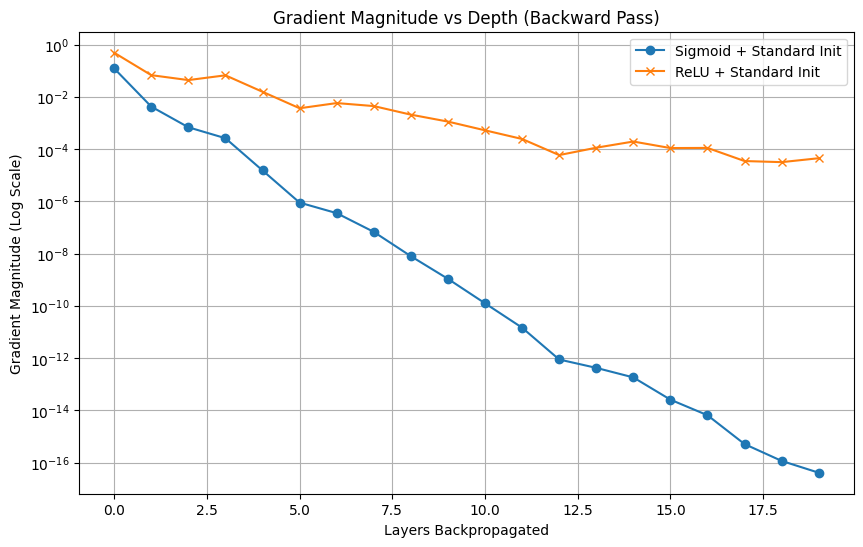